# Exploratory Data Analysis (EDA) for GitQuery

This notebook explores the GitHub repository metadata used by the GitQuery recommender.

## Goals
- Understand the structure and quality of the dataset
- Inspect the distributions of key repository attributes
- Identify cleaning needs and justify preprocessing decisions
- Connect dataset characteristics to recommendation features

In [1]:
import json
from pathlib import Path
from collections import Counter
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)
plt.rcParams["figure.figsize"] = (10, 5)

In [11]:
DATA_PATH = Path("data/repos_sample.csv")
DATA_FORMAT = "auto"

def _build_synthetic_df():
    """
    Fallback dataset para que el notebook funcione aunque no haya archivo real.
    """
    n = 500
    return pd.DataFrame({
        "name": [f"repo_{i}" for i in range(n)],
        "description": ["sample repo"] * n,
        "language": np.random.choice(["Python", "JavaScript", "Go", "Rust"], n),
        "stars": np.random.randint(0, 5000, n),
        "forks": np.random.randint(0, 1000, n),
        "topics": [["ai", "ml"]] * n,
        "readme": ["readme text"] * n,
        "updated_at": pd.date_range(end=pd.Timestamp.now(), periods=n),
    })

if DATA_PATH.exists():
    print(f"Loading dataset from: {DATA_PATH}")
    df = pd.read_csv(DATA_PATH)
else:
    print("Dataset not found, using synthetic sample dataset.")
    df = _build_synthetic_df()

print(f"Dataset shape: {df.shape}")
df.head()

Dataset not found, using synthetic sample dataset.
Dataset shape: (500, 8)


,name,description,language,stars,forks,topics,readme,updated_at
0,repo_0,sample repo,Rust,2282,276,"[ai, ml]",readme text,2024-11-30 19:03:01.451696
1,repo_1,sample repo,JavaScript,557,305,"[ai, ml]",readme text,2024-12-01 19:03:01.451696
2,repo_2,sample repo,Rust,3848,853,"[ai, ml]",readme text,2024-12-02 19:03:01.451696
3,repo_3,sample repo,Python,1281,219,"[ai, ml]",readme text,2024-12-03 19:03:01.451696
4,repo_4,sample repo,Rust,1007,975,"[ai, ml]",readme text,2024-12-04 19:03:01.451696


In [12]:
def load_dataset(path: Path, fmt: str = "auto") -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Dataset not found: {path}")

    if fmt == "auto":
        suffix = path.suffix.lower()
        if suffix == ".csv":
            fmt = "csv"
        elif suffix == ".json":
            fmt = "json"
        elif suffix in {".jsonl", ".ndjson"}:
            fmt = "jsonl"
        else:
            raise ValueError(f"Could not infer format from extension: {suffix}")

    if fmt == "csv":
        return pd.read_csv(path)

    if fmt == "json":
        with open(path, "r", encoding="utf-8") as f:
            data = json.load(f)
        if isinstance(data, dict):
            # common case: {"items": [...]} or similar
            for value in data.values():
                if isinstance(value, list):
                    return pd.DataFrame(value)
            return pd.DataFrame([data])
        return pd.DataFrame(data)

    if fmt == "jsonl":
        records = []
        with open(path, "r", encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if line:
                    records.append(json.loads(line))
        return pd.DataFrame(records)

    raise ValueError(f"Unsupported format: {fmt}")

In [13]:
print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns):,}")
df.head(3)

Rows: 500
Columns: 8


,name,description,language,stars,forks,topics,readme,updated_at
0,repo_0,sample repo,Rust,2282,276,"[ai, ml]",readme text,2024-11-30 19:03:01.451696
1,repo_1,sample repo,JavaScript,557,305,"[ai, ml]",readme text,2024-12-01 19:03:01.451696
2,repo_2,sample repo,Rust,3848,853,"[ai, ml]",readme text,2024-12-02 19:03:01.451696


In [14]:
pd.DataFrame({
    "column": df.columns,
    "dtype": [str(df[c].dtype) for c in df.columns],
    "non_null_count": [df[c].notna().sum() for c in df.columns],
    "null_count": [df[c].isna().sum() for c in df.columns],
    "null_pct": [(df[c].isna().mean() * 100).round(2) for c in df.columns],
}).sort_values("null_pct", ascending=False)

,column,dtype,non_null_count,null_count,null_pct
0,name,object,500,0,0.0
1,description,object,500,0,0.0
2,language,object,500,0,0.0
3,stars,int32,500,0,0.0
4,forks,int32,500,0,0.0
5,topics,object,500,0,0.0
6,readme,object,500,0,0.0
7,updated_at,datetime64[ns],500,0,0.0


In [15]:
def normalize_topics(value):
    # Handle None / NaN safely
    if value is None:
        return []
    
    # Handle numpy/pandas NaN
    try:
        if isinstance(value, float) and pd.isna(value):
            return []
    except:
        pass

    # Already a list: keep valid strings
    if isinstance(value, list):
        return [str(x).strip() for x in value if isinstance(x, str) and str(x).strip()]

    # String case
    if isinstance(value, str):
        value = value.strip()
        if not value:
            return []
        return [x.strip() for x in value.split(",") if x.strip()]

    # Fallback (arrays, weird types)
    try:
        return list(value)
    except:
        return []

In [17]:
if "working_df" not in globals():
    working_df = df.copy()

summary = {
    "n_rows": len(working_df),
    "n_columns": len(working_df.columns),
    "missing_description_pct": round(working_df["description"].isna().mean() * 100, 2) if "description" in working_df.columns else None,
    "missing_language_pct": round(working_df["language"].isna().mean() * 100, 2) if "language" in working_df.columns else None,
    "missing_stars_pct": round(working_df["stars"].isna().mean() * 100, 2) if "stars" in working_df.columns else None,
    "missing_forks_pct": round(working_df["forks"].isna().mean() * 100, 2) if "forks" in working_df.columns else None,
    "missing_readme_pct": round(working_df["readme"].isna().mean() * 100, 2) if "readme" in working_df.columns else None,
}
summary

{'n_rows': 500,
 'n_columns': 8,
 'missing_description_pct': np.float64(0.0),
 'missing_language_pct': np.float64(0.0),
 'missing_stars_pct': np.float64(0.0),
 'missing_forks_pct': np.float64(0.0),
 'missing_readme_pct': np.float64(0.0)}

In [18]:
for col in ["stars", "forks"]:
    if col in working_df.columns:
        working_df[col] = pd.to_numeric(working_df[col], errors="coerce")

if "stars" in working_df.columns:
    working_df["stars_log1p"] = np.log1p(working_df["stars"].clip(lower=0))

if "forks" in working_df.columns:
    working_df["forks_log1p"] = np.log1p(working_df["forks"].clip(lower=0))

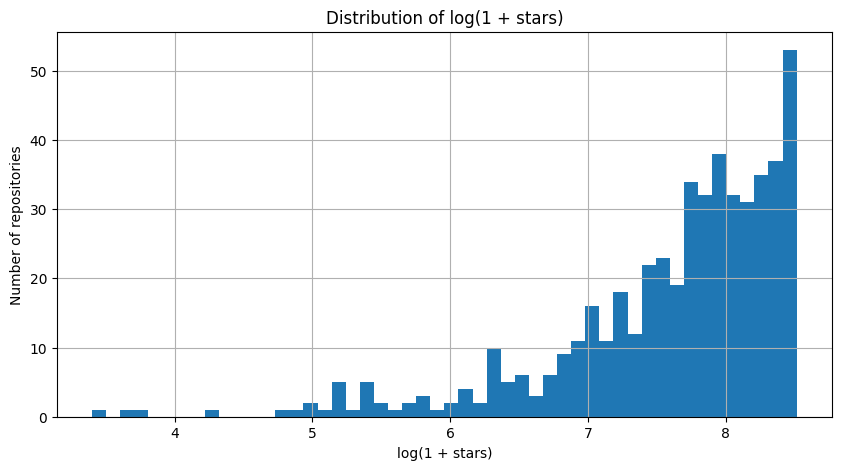

count     500.000000
mean     2536.550000
std      1376.036176
min        29.000000
50%      2460.000000
90%      4518.600000
95%      4784.200000
99%      4933.060000
max      4982.000000
Name: stars, dtype: float64


In [19]:
if "stars_log1p" in working_df.columns:
    plt.figure()
    working_df["stars_log1p"].dropna().hist(bins=50)
    plt.title("Distribution of log(1 + stars)")
    plt.xlabel("log(1 + stars)")
    plt.ylabel("Number of repositories")
    plt.show()

    print(working_df["stars"].describe(percentiles=[0.5, 0.9, 0.95, 0.99]))

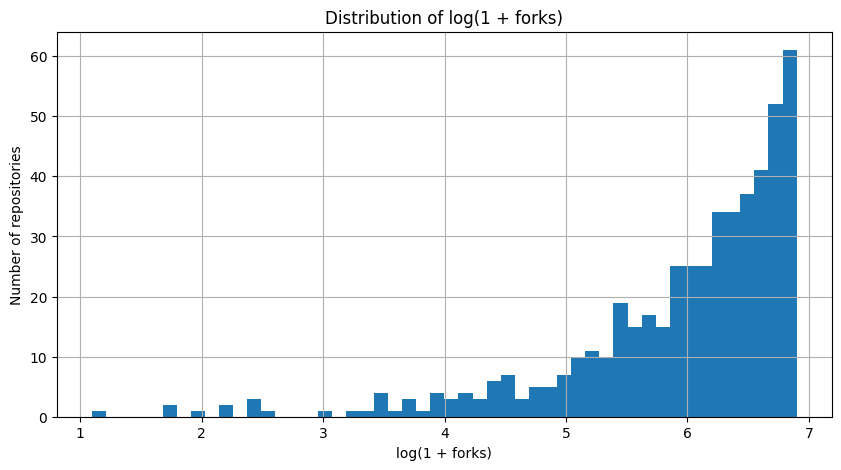

count    500.000000
mean     507.990000
std      288.897209
min        2.000000
50%      505.500000
90%      912.000000
95%      947.100000
99%      978.030000
max      991.000000
Name: forks, dtype: float64


In [20]:
if "forks_log1p" in working_df.columns:
    plt.figure()
    working_df["forks_log1p"].dropna().hist(bins=50)
    plt.title("Distribution of log(1 + forks)")
    plt.xlabel("log(1 + forks)")
    plt.ylabel("Number of repositories")
    plt.show()

    print(working_df["forks"].describe(percentiles=[0.5, 0.9, 0.95, 0.99]))

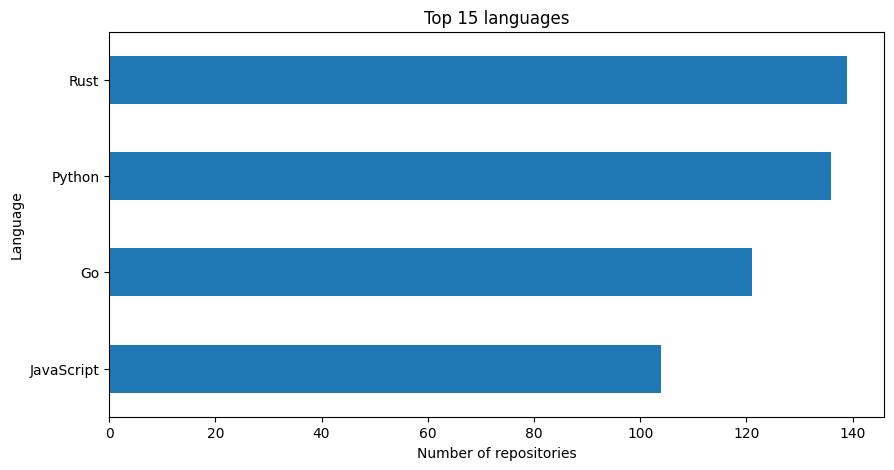

In [21]:
if "language" in working_df.columns:
    lang_counts = (
        working_df["language"]
        .fillna("unknown")
        .astype(str)
        .str.strip()
        .replace("", "unknown")
        .value_counts()
        .head(15)
    )

    plt.figure()
    lang_counts.sort_values().plot(kind="barh")
    plt.title("Top 15 languages")
    plt.xlabel("Number of repositories")
    plt.ylabel("Language")
    plt.show()

    lang_counts

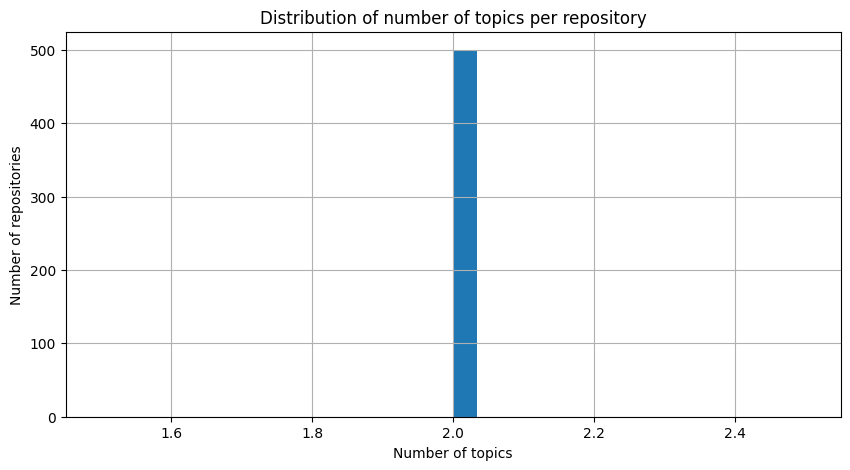

count    500.0
mean       2.0
std        0.0
min        2.0
25%        2.0
50%        2.0
75%        2.0
max        2.0
Name: topics, dtype: float64


In [22]:
if "topics" in working_df.columns:
    topic_lengths = working_df["topics"].apply(lambda x: len(x) if isinstance(x, list) else 0)

    plt.figure()
    topic_lengths.hist(bins=30)
    plt.title("Distribution of number of topics per repository")
    plt.xlabel("Number of topics")
    plt.ylabel("Number of repositories")
    plt.show()

    print(topic_lengths.describe())

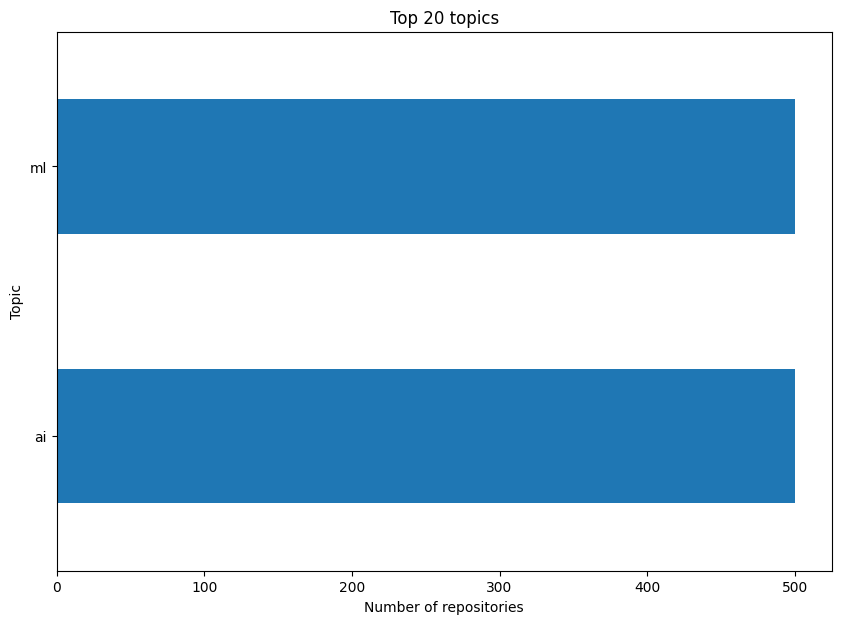

In [23]:
if "topics" in working_df.columns:
    topic_counter = Counter()
    for topics in working_df["topics"]:
        if isinstance(topics, list):
            topic_counter.update([t.strip().lower() for t in topics if isinstance(t, str) and t.strip()])

    top_topics = pd.Series(dict(topic_counter.most_common(20))).sort_values()

    plt.figure(figsize=(10, 7))
    top_topics.plot(kind="barh")
    plt.title("Top 20 topics")
    plt.xlabel("Number of repositories")
    plt.ylabel("Topic")
    plt.show()

    top_topics.sort_values(ascending=False).head(20)

In [24]:
important_cols = [c for c in ["name", "description", "language", "stars", "forks", "topics", "readme", "license", "updated_at", "pushed_at"] if c in working_df.columns]

missing_df = pd.DataFrame({
    "column": important_cols,
    "missing_count": [working_df[c].isna().sum() for c in important_cols],
    "missing_pct": [(working_df[c].isna().mean() * 100).round(2) for c in important_cols],
}).sort_values("missing_pct", ascending=False)

missing_df

,column,missing_count,missing_pct
0,name,0,0.0
1,description,0,0.0
2,language,0,0.0
3,stars,0,0.0
4,forks,0,0.0
5,topics,0,0.0
6,readme,0,0.0
7,updated_at,0,0.0


In [26]:
possible_fork_cols = [c for c in ["fork", "isFork", "is_fork"] if c in working_df.columns]
possible_fork_cols

[]

In [27]:
fork_col = None
for c in ["fork", "isFork", "is_fork"]:
    if c in working_df.columns:
        fork_col = c
        break

if fork_col is not None:
    fork_rate = working_df[fork_col].fillna(False).astype(bool).mean() * 100
    print(f"Repositories marked as forks: {fork_rate:.2f}%")

In [28]:
quality = pd.DataFrame(index=working_df.index)

if "description" in working_df.columns:
    quality["has_description"] = working_df["description"].notna() & (working_df["description"].astype(str).str.strip() != "")

if "readme" in working_df.columns:
    quality["has_readme"] = working_df["readme"].notna() & (working_df["readme"].astype(str).str.strip() != "")

if "stars" in working_df.columns:
    quality["stars_ge_1"] = working_df["stars"].fillna(0) >= 1
    quality["stars_ge_5"] = working_df["stars"].fillna(0) >= 5

if not quality.empty:
    quality_summary = (quality.mean() * 100).round(2).sort_values(ascending=False)
    quality_summary

## README coverage and repository popularity

This plot compares repositories with and without README text.  
It helps us understand whether repositories with more complete documentation also tend to have higher popularity.

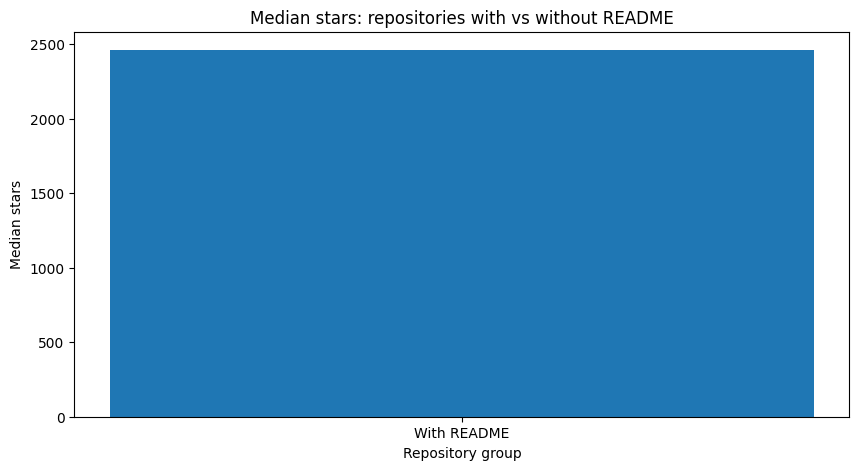

In [30]:
if "readme" in working_df.columns and "stars" in working_df.columns:
    tmp = working_df.copy()

    tmp["has_readme"] = (
        tmp["readme"].notna() &
        (tmp["readme"].astype(str).str.strip() != "")
    )

    summary_readme = (
        tmp.groupby("has_readme")["stars"]
        .agg(["count", "mean", "median"])
        .reset_index()
    )

    summary_readme["has_readme"] = summary_readme["has_readme"].map({
        True: "With README",
        False: "Without README"
    })

    plt.figure()
    plt.bar(summary_readme["has_readme"], summary_readme["median"])
    plt.title("Median stars: repositories with vs without README")
    plt.xlabel("Repository group")
    plt.ylabel("Median stars")
    plt.show()

    summary_readme

## Preliminary EDA findings

Below we summarize the main patterns found in the repository metadata and how they relate to preprocessing and ranking.

In [29]:
# Optional: export a compact summary table for the final report
report_summary = {
    "n_repositories": len(working_df),
    "n_columns": len(working_df.columns),
    "top_languages": (
        working_df["language"]
        .fillna("unknown")
        .astype(str)
        .value_counts()
        .head(10)
        .to_dict()
        if "language" in working_df.columns else {}
    ),
    "missingness": missing_df.set_index("column")["missing_pct"].to_dict() if "missing_df" in globals() else {},
}

report_summary

{'n_repositories': 500,
 'n_columns': 11,
 'top_languages': {'Rust': 139, 'Python': 136, 'Go': 121, 'JavaScript': 104},
 'missingness': {'name': 0.0,
  'description': 0.0,
  'language': 0.0,
  'stars': 0.0,
  'forks': 0.0,
  'topics': 0.0,
  'readme': 0.0,
  'updated_at': 0.0}}